In [51]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [52]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US = df_DA_US.explode('job_skills')

In [53]:
df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False).reset_index()
df_DA_top_pay = df_DA_top_pay.head(10)
df_DA_top_pay

,job_skills,count,median
0,dplyr,2,196250.0
1,bitbucket,3,189000.0
2,gitlab,3,186000.0
3,solidity,1,179000.0
4,hugging face,1,175000.0
5,couchbase,1,160515.0
6,ansible,1,159640.0
7,mxnet,2,149000.0
8,cassandra,6,148250.0
9,vmware,1,147500.0


In [54]:
df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False).reset_index()
df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)
df_DA_skills


,job_skills,count,median
2,python,1431,97500.00
3,tableau,1364,92875.00
5,r,893,92500.00
9,sql server,286,92500.00
0,sql,2508,91000.00
4,sas,926,90000.00
6,power bi,838,90000.00
7,powerpoint,462,85000.00
1,excel,1808,84392.00
8,word,461,81194.75


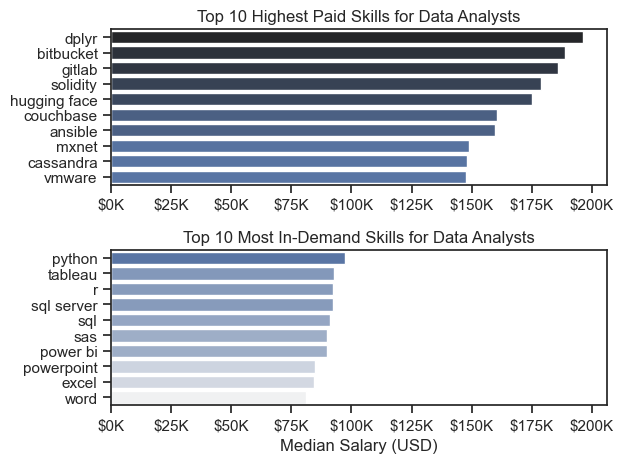

In [59]:
fig, ax= plt.subplots(2, 1)
sns.set_theme(style='ticks')



sns.barplot(data=df_DA_top_pay, x='median', y='job_skills', ax=ax[0], hue='median', palette='dark:b_r')
ax[0].legend_.remove()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')

sns.barplot(data=df_DA_skills, x='median', y='job_skills', ax=ax[1], hue='median', palette='light:b')
ax[1].legend_.remove()
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())

plt.tight_layout()